## **Reference Landscape projection - ETV6-RUNX1 scRNA seq data**

In [1]:
#reference: Kucinski et al., Cell Stem Cell 2024

In [2]:
import os
import numpy as np 
import cellproject as cp
import pandas as pd 
import scanpy as sc 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches 
import pathlib 
import pickle 
import warnings 

/home/l172n/virtualenvs/cellproject/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
warnings.filterwarnings("ignore", category=FutureWarning) 

In [4]:
os.chdir('/omics/odcf/analysis/OE0650_projects/rach_seq/src/l172n/reference_landscape/HSPCdynamics_code')

sc.settings.verbosity = 3
base_figures = './figures/preleukemic_projection/'
base_procdata = './procdata/preleukemic_projection/'
sc.settings.figdir = base_figures
for d in [base_figures, base_procdata]:
    pathlib.Path(d).mkdir(parents=True, exist_ok=True)

#### **Load Data**

In [5]:
ref = sc.read('./procdata/04script/combined_filt.h5ad')
ref = ref[ref.obs.data_type == '10x', :].copy() #filter to 10x genomics data to make my data
 
query_sub = sc.read('./procdata/preleukemic_projection/preleukemic_projected.h5ad')
 
# Subset reference to common genes
ref_sub = ref[:, query_sub.var_names].copy() 
ref_sub.obs['source'] = 'reference'
query_sub.obs['source'] = query_sub.obs['sample_group']
 
combined = ref_sub.concatenate(query_sub, batch_key='concat_batch', index_unique=None)
combined.obs = combined.obs.astype(str) #convert metadata columns to string type for plotting later

#### **Load RUNX1 exon5-9 barcodes(thresold min 2 reads)**

In [6]:
base_path = '/omics/odcf/analysis/OE0650_projects/rach_seq/src/l172n/txt_files/'
 
def load_barcodes(path, prefix):
    barcodes = open(path).read().splitlines()
    return [f'{prefix}_{b}-1' for b in barcodes if b] #skip emtpy lines 
 
barcodes_s1   = load_barcodes(base_path + 'RUNX1_exons5to9_Sample1_barcodes_min2.txt', 'S1')
barcodes_s2   = load_barcodes(base_path + 'RUNX1_exons5to9_Sample2_barcodes_min2.txt', 'S2')
barcodes_s3   = load_barcodes(base_path + 'RUNX1_exons5to9_Sample3_barcodes_min2.txt', 'S3')
barcodes_ctrl = load_barcodes(base_path + 'RUNX1_exons5to9_Control_barcodes_min2.txt', 'C')
 
all_runx1_min2 = set(barcodes_s1 + barcodes_s2 + barcodes_s3 + barcodes_ctrl) #set() converts to a set (removes duplicates, enables fast lookup)
query_sub.obs['RUNX1_exon5to9_min2'] = query_sub.obs.index.isin(all_runx1_min2)
 
print("RUNX1 exon5-9 min2 positive cells per sample:")
print(query_sub.obs[query_sub.obs['RUNX1_exon5to9_min2']].groupby('sample_group').size())


RUNX1 exon5-9 min2 positive cells per sample:
sample_group
Control     0
Sample1    24
Sample2    26
Sample3    50
dtype: int64


#### **cell type colors and centroids(SIngleR labels)**

In [7]:
cluster_colors = {
    'Neutrophils':  'purple',
    'B cells':      'steelblue',
    'Stem cells':   'limegreen',
    'Monocytes':    'orchid',
    'B cells, pro': 'red',
    'T cells':      'orange',
    'Basophils':    'hotpink',
    'NK cells':     'brown',
    'NKT':          'darkgreen',
    'DC':           'blue',
    'Macrophages':  '#FFD700',
}
 
# Auto-calculate centroids
singler_centroids = {}
for label in cluster_colors:
    mask = (combined.obs['SingleR_label'] == label) & (combined.obs['source'] != 'reference')
    if mask.sum() > 0:
        singler_centroids[label] = (
            combined.obsm['X_umap'][mask, 0].mean(),
            combined.obsm['X_umap'][mask, 1].mean(),
        )
 
# Manual adjustments for overlapping labels
singler_centroids['B cells']      = (13,    11)
singler_centroids['Stem cells']   = (-1,    -4)
singler_centroids['DC']           = (-4.5,  10.5)
singler_centroids['Monocytes']    = (-2,    11)
singler_centroids['B cells, pro'] = (-5,    13.5)
singler_centroids['T cells']      = (-4.9,  3)
singler_centroids['Basophils']    = (-0.8,  6.2)
singler_centroids['NK cells']     = (-4.3,  8)
singler_centroids['NKT']          = (-6.9,  6)
singler_centroids['Macrophages']  = (7.8,  -5.22)
 
samples       = ['Control', 'Sample1', 'Sample2', 'Sample3']
sample_colors = {'Control': '#FF5722', 'Sample1': '#2196F3',
                 'Sample2': '#4CAF50',  'Sample3': '#9C27B0'}
 

#### **reference landscape**

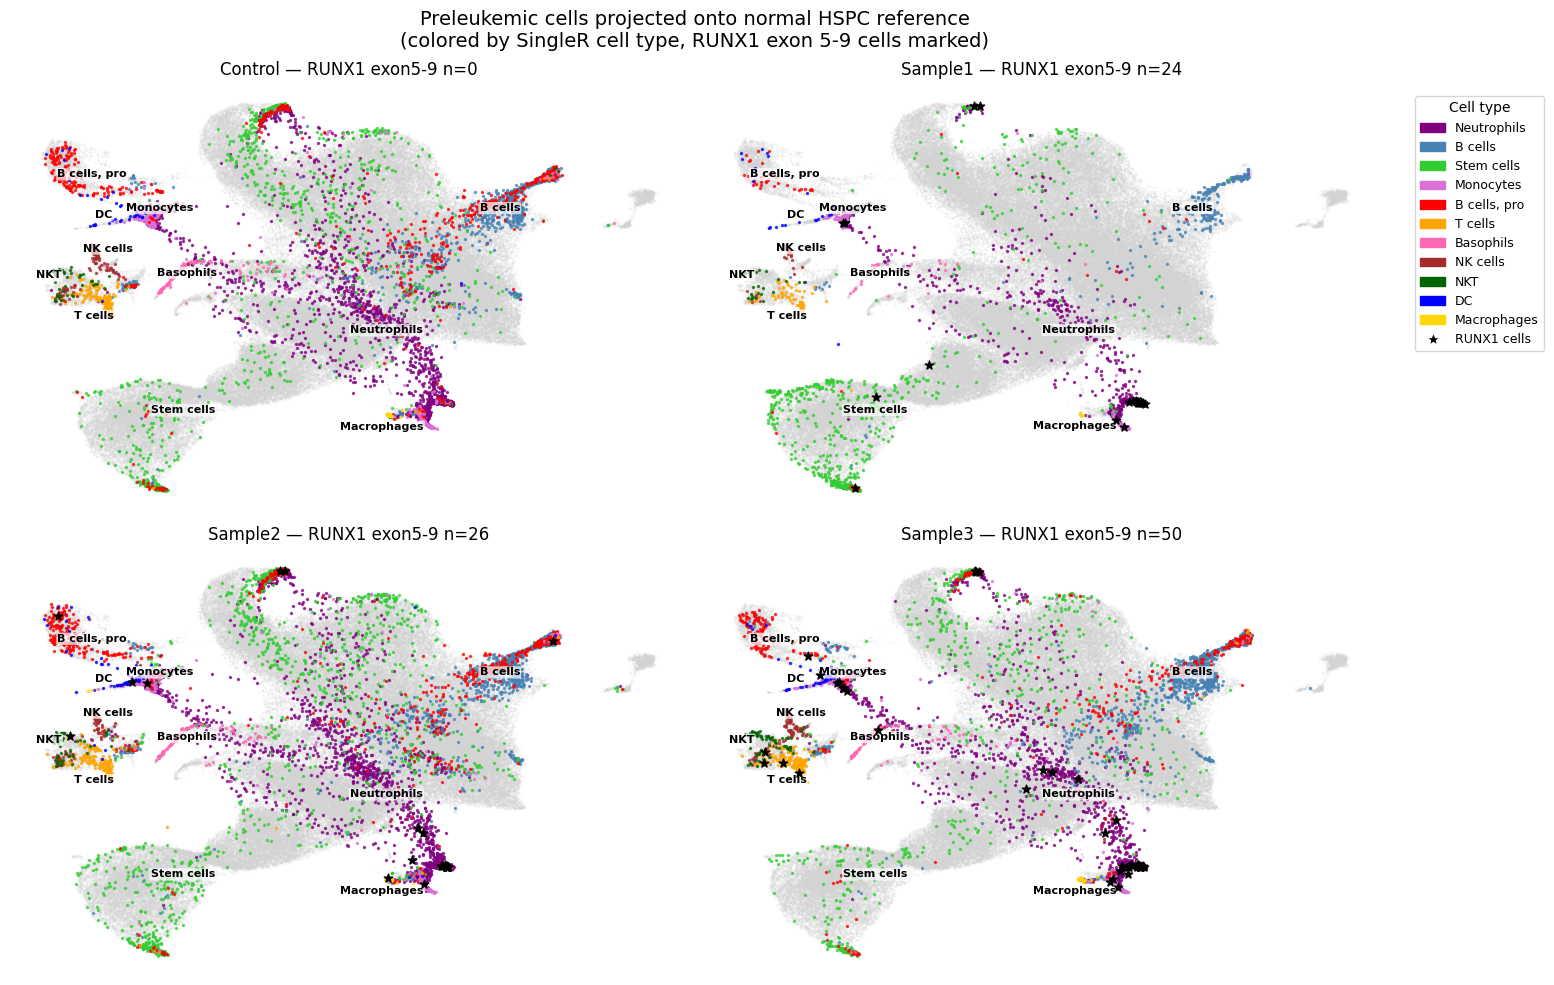

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
 
for ax, sample in zip(axes, samples):
    # Grey reference background
    ref_mask = combined.obs['source'] == 'reference'
    ax.scatter(combined.obsm['X_umap'][ref_mask, 0],
               combined.obsm['X_umap'][ref_mask, 1],
               c='lightgrey', s=0.3, alpha=0.2, rasterized=True)
 
    # Cell type labels
    for label, (cx, cy) in singler_centroids.items():
        ax.text(cx, cy, label, fontsize=8, ha='center', va='center',
                fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.7, linewidth=0))
 
    # Color cells by SingleR label
    sample_idx  = np.where(combined.obs['source'] == sample)[0]
    sample_anno = combined.obs['SingleR_label'].iloc[sample_idx].values
    sample_umap = combined.obsm['X_umap'][sample_idx]
 
    for cluster, color in cluster_colors.items():
        mask = sample_anno == cluster
        if mask.sum() > 0:
            ax.scatter(sample_umap[mask, 0], sample_umap[mask, 1],
                       c=color, s=2, alpha=0.7, rasterized=True)
 
    # RUNX1 exon 5-9 positive cells as black stars
    runx1_mask = (query_sub.obs['sample_group'] == sample) & \
                 (query_sub.obs['RUNX1_exon5to9_min2'] == True)
    if runx1_mask.sum() > 0:
        ax.scatter(query_sub.obsm['X_umap'][runx1_mask, 0],
                   query_sub.obsm['X_umap'][runx1_mask, 1],
                   c='black', s=40, alpha=1, marker='*', zorder=5)
 
    ax.set_title(f'{sample} — RUNX1 exon5-9 n={runx1_mask.sum()}', fontsize=12)
    ax.axis('off')
 
legend_handles = [mpatches.Patch(color=c, label=l) for l, c in cluster_colors.items()]
legend_handles.append(plt.Line2D([0], [0], marker='*', color='w',
                                  markerfacecolor='black', markersize=10, label='RUNX1 cells'))
fig.legend(handles=legend_handles, title='Cell type',
           bbox_to_anchor=(1.01, 0.9), loc='upper left', fontsize=9)
plt.suptitle('Preleukemic cells projected onto normal HSPC reference\n'
             '(colored by SingleR cell type, RUNX1 exon 5-9 cells marked)', fontsize=14)
plt.tight_layout()
plt.savefig(base_figures + 'overlay_singler_runx1.pdf', dpi=300, bbox_inches='tight')
plt.savefig(base_figures + 'overlay_singler_runx1.png', dpi=300, bbox_inches='tight')
plt.show()

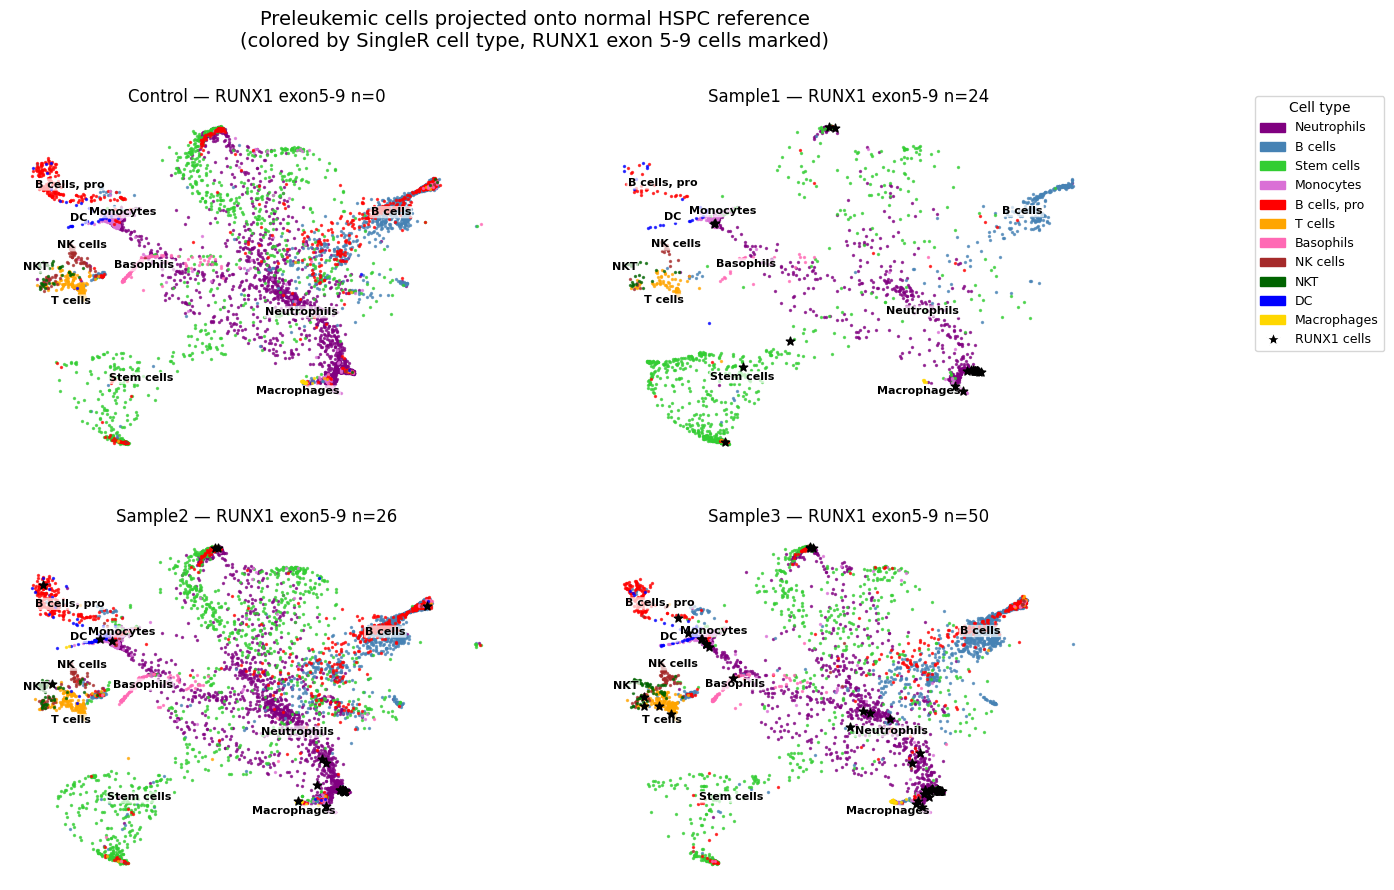

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, sample in zip(axes, samples):
    # Cell type labels
    for label, (cx, cy) in singler_centroids.items():
        ax.text(cx, cy, label, fontsize=8, ha='center', va='center',
                fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.7, linewidth=0))

    # Color cells by SingleR label
    sample_idx  = np.where(combined.obs['source'] == sample)[0]
    sample_anno = combined.obs['SingleR_label'].iloc[sample_idx].values
    sample_umap = combined.obsm['X_umap'][sample_idx]

    for cluster, color in cluster_colors.items():
        mask = sample_anno == cluster
        if mask.sum() > 0:
            ax.scatter(sample_umap[mask, 0], sample_umap[mask, 1],
                       c=color, s=2, alpha=0.7, rasterized=True)

    # RUNX1 exon 5-9 positive cells as black stars
    runx1_mask = (query_sub.obs['sample_group'] == sample) & \
                 (query_sub.obs['RUNX1_exon5to9_min2'] == True)
    if runx1_mask.sum() > 0:
        ax.scatter(query_sub.obsm['X_umap'][runx1_mask, 0],
                   query_sub.obsm['X_umap'][runx1_mask, 1],
                   c='black', s=40, alpha=1, marker='*', zorder=5)

    ax.set_title(f'{sample} — RUNX1 exon5-9 n={runx1_mask.sum()}', fontsize=12)
    ax.axis('off')

legend_handles = [mpatches.Patch(color=c, label=l) for l, c in cluster_colors.items()]
legend_handles.append(plt.Line2D([0], [0], marker='*', color='w',
                                  markerfacecolor='black', markersize=10, label='RUNX1 cells'))
fig.legend(handles=legend_handles, title='Cell type',
           bbox_to_anchor=(1.01, 0.9), loc='upper left', fontsize=9)
plt.suptitle('Preleukemic cells projected onto normal HSPC reference\n'
             '(colored by SingleR cell type, RUNX1 exon 5-9 cells marked)', fontsize=14)


#plt.savefig(base_figures + 'overlay_singler_runx1_nogrey.pdf', dpi=300, bbox_inches='tight')
#plt.savefig(base_figures + 'overlay_singler_runx1_nogrey.png', dpi=300, bbox_inches='tight')
plt.show()

### **Reference landscape with papers labeling**

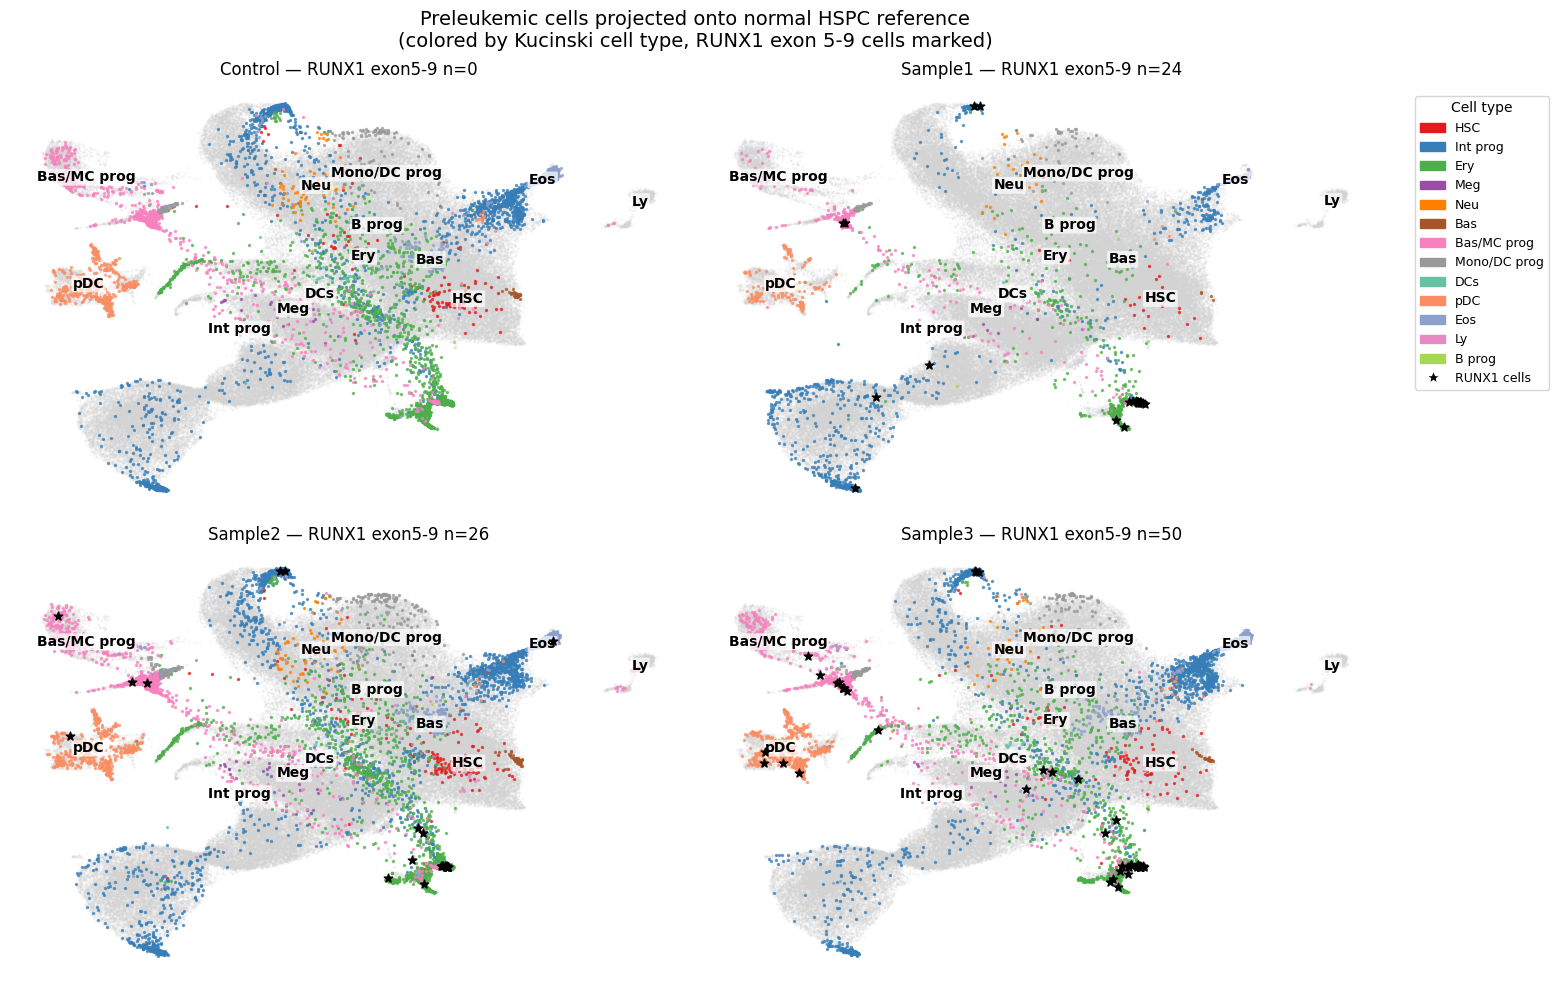

In [11]:
ref_cells_mask = combined.obs['source'] == 'reference'
ref_umap = combined.obsm['X_umap'][ref_cells_mask]
ref_anno = combined.obs.loc[ref_cells_mask, 'anno_man']

anno_centroids = {}
for label in ref_anno.unique():
    mask = (ref_anno == label).values
    anno_centroids[label] = (ref_umap[mask, 0].mean(), ref_umap[mask, 1].mean())

# Manual adjustments
anno_centroids['Int prog'] = (1.5, 2.0)
anno_centroids['Meg'] = (3.9, 3.5)
cluster_colors = {
    'HSC': '#e41a1c',
    'Int prog': '#377eb8', 
    'Ery': '#4daf4a',
    'Meg': '#984ea3',
    'Neu': '#ff7f00',
    'Bas': '#a65628',
    'Bas/MC prog': '#f781bf',
    'Mono/DC prog': '#999999',
    'DCs': '#66c2a5',
    'pDC': '#fc8d62',
    'Eos': '#8da0cb',
    'Ly': '#e78ac3',
    'B prog': '#a6d854',
}

anno_centroids['Int prog'] = (1.5, 2.0)
anno_centroids['Meg'] = (3.9, 3.5)

np.random.seed(42)
n_sample = 4641
samples = ['Control', 'Sample1', 'Sample2', 'Sample3']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, sample in zip(axes, samples):
    # Grey reference background
    ref_mask = combined.obs['source'] == 'reference'
    ax.scatter(combined.obsm['X_umap'][ref_mask, 0],
               combined.obsm['X_umap'][ref_mask, 1],
               c='lightgrey', s=0.3, alpha=0.2, rasterized=True)
    
    # Add cluster labels
    for label, (cx, cy) in anno_centroids.items():
        ax.text(cx, cy, label, fontsize=10, ha='center', va='center',
                fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.7, linewidth=0))
    
    sample_idx = np.where(combined.obs['source'] == sample)[0]
    
    # Color by Kucinski ref_anno_man
    sample_anno = combined.obs['ref_anno_man'].iloc[sample_idx].values
    sample_umap = combined.obsm['X_umap'][sample_idx]
    
    for cluster, color in cluster_colors.items():
        cluster_mask = sample_anno == cluster
        if cluster_mask.sum() > 0:
            ax.scatter(sample_umap[cluster_mask, 0],
                       sample_umap[cluster_mask, 1],
                       c=color, s=2, alpha=0.7, rasterized=True)
    
    # RUNX1 exon 5-9 min2 positive cells as black stars
    runx1_mask = (query_sub.obs['sample_group'] == sample) & \
                 (query_sub.obs['RUNX1_exon5to9_min2'] == True)
    if runx1_mask.sum() > 0:
        ax.scatter(query_sub.obsm['X_umap'][runx1_mask, 0],
                   query_sub.obsm['X_umap'][runx1_mask, 1],
                   c='black', s=40, alpha=1, marker='*', zorder=5)
    
    ax.set_title(f'{sample} — RUNX1 exon5-9 n={runx1_mask.sum()}', fontsize=12)
    ax.axis('off')

legend_handles = [mpatches.Patch(color=c, label=l) for l, c in cluster_colors.items()]
legend_handles.append(plt.Line2D([0], [0], marker='*', color='w',
                                  markerfacecolor='black', markersize=10, label='RUNX1 cells'))
fig.legend(handles=legend_handles, title='Cell type',
           bbox_to_anchor=(1.01, 0.9), loc='upper left', fontsize=9)
plt.suptitle('Preleukemic cells projected onto normal HSPC reference\n'
             '(colored by Kucinski cell type, RUNX1 exon 5-9 cells marked)', fontsize=14)
plt.tight_layout()


#### **Barplot**

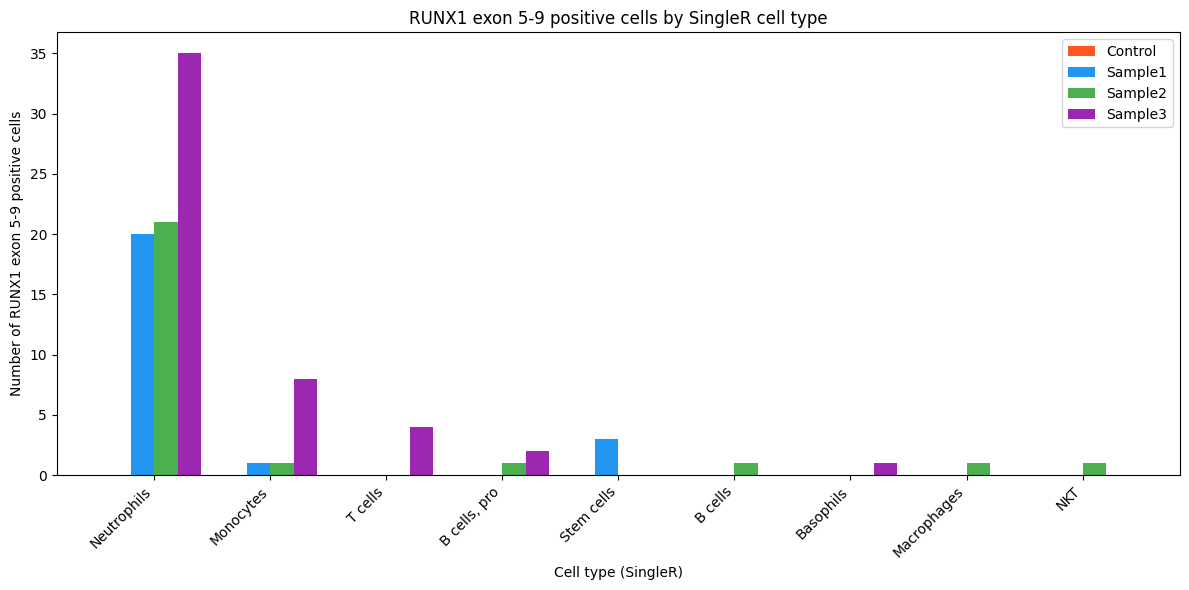

In [12]:
keep_celltypes_singler = ['Neutrophils', 'Monocytes', 'T cells', 'B cells, pro', 
                           'Stem cells', 'B cells', 'Basophils', 'Macrophages', 'NKT']

runx1_bar_singler = query_sub.obs[query_sub.obs['RUNX1_exon5to9_min2']][['sample_group', 'SingleR_label']].copy()
runx1_bar_singler = runx1_bar_singler[runx1_bar_singler['SingleR_label'].isin(keep_celltypes_singler)]
counts_singler = runx1_bar_singler.groupby(['sample_group', 'SingleR_label']).size().reset_index(name='n')

x     = range(len(keep_celltypes_singler))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
for i, sample in enumerate(samples):
    sd = counts_singler[counts_singler['sample_group'] == sample]
    vals = [sd[sd['SingleR_label'] == ct]['n'].values[0]
            if ct in sd['SingleR_label'].values else 0
            for ct in keep_celltypes_singler]
    ax.bar([xi + i * width for xi in x], vals, width,
           label=sample, color=sample_colors[sample])

ax.set_xticks([xi + 1.5 * width for xi in x])
ax.set_xticklabels(keep_celltypes_singler, rotation=45, ha='right')
ax.set_xlabel('Cell type (SingleR)')
ax.set_ylabel('Number of RUNX1 exon 5-9 positive cells')
ax.set_title('RUNX1 exon 5-9 positive cells by SingleR cell type')
ax.legend()
plt.tight_layout()
plt.show()

## **Scanpy.ingest**

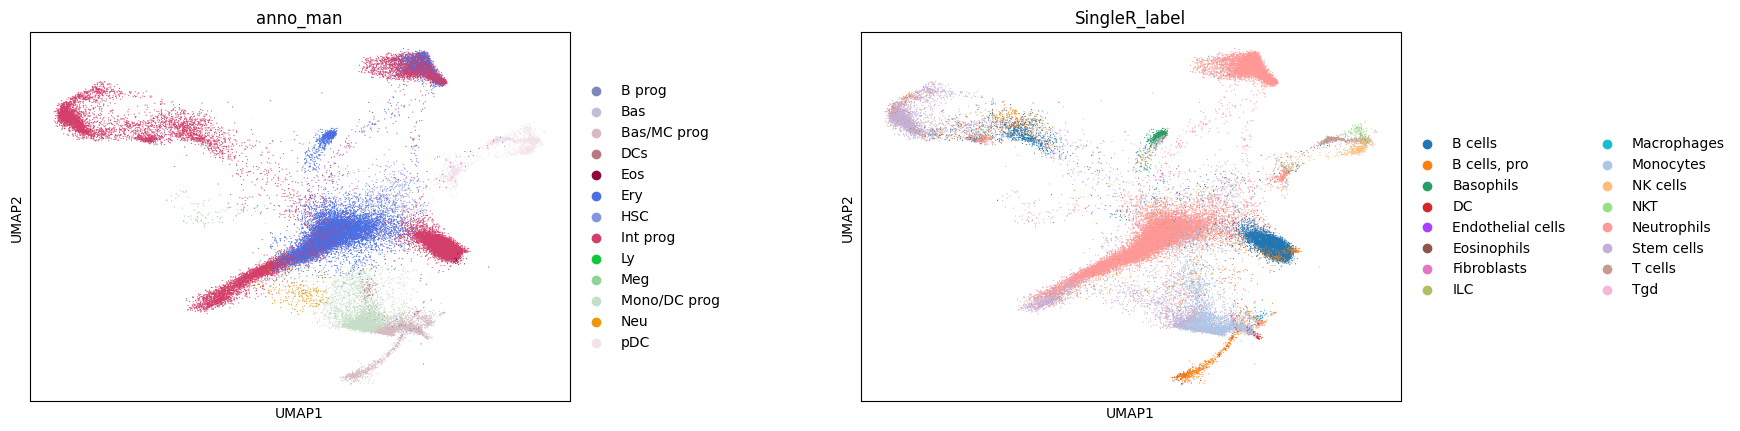

In [16]:
import scanpy as sc

# load the already-ingested query cells (from the completed job)
adata = sc.read_h5ad("/omics/odcf/analysis/OE0650_projects/rach_seq/src/l172n/obj_mouse_export/adata_ingested.h5ad")

# consistency check: new reference-based labels vs your original SingleR labels
sc.pl.umap(adata, color=["anno_man", "SingleR_label"], wspace=0.4)

In [18]:
# check group sizes
print(adata.obs['anno_man'].value_counts())

anno_man
Int prog        23003
Ery             13713
Mono/DC prog     3354
Bas/MC prog      2820
pDC              1621
HSC               587
Neu               317
DCs               142
Meg               109
Eos                49
Ly                  2
Bas                 0
B prog              0
Name: count, dtype: int64


In [19]:
# filter out groups with too few cells (need at least 3 to run the stats test)
counts = adata.obs['anno_man'].value_counts()
valid_groups = counts[counts >= 3].index.tolist()

adata_sub = adata[adata.obs['anno_man'].isin(valid_groups)].copy()
adata_sub.obs['anno_man'] = adata_sub.obs['anno_man'].cat.remove_unused_categories()

In [20]:
# run the marker gene test on the filtered data
sc.tl.rank_genes_groups(adata_sub, groupby='anno_man', method='wilcoxon')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:07:18)


    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_anno_man']`


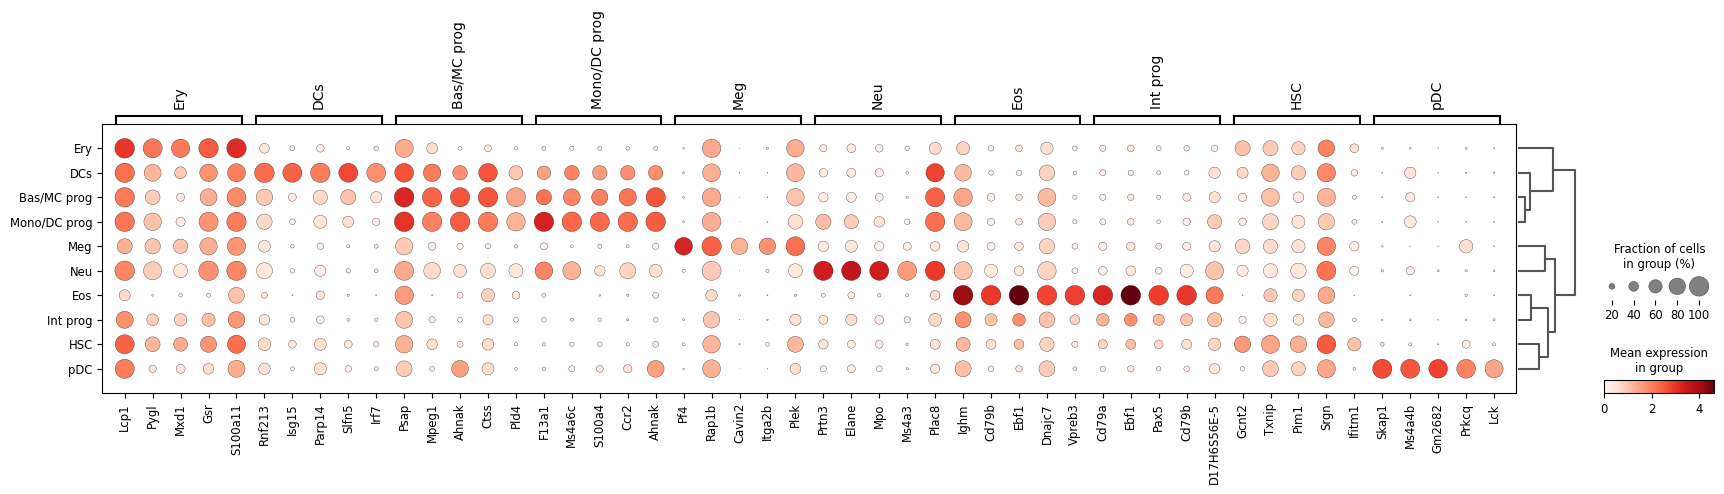

In [21]:
sc.pl.rank_genes_groups_dotplot(adata_sub, n_genes=5, groupby='anno_man')

In [23]:
# filter out tiny groups
counts = adata.obs['SingleR_label'].value_counts()
valid_groups = counts[counts >= 3].index.tolist()

adata_sub_singler = adata[adata.obs['SingleR_label'].isin(valid_groups)].copy()
adata_sub_singler.obs['SingleR_label'] = adata_sub_singler.obs['SingleR_label'].cat.remove_unused_categories()

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:08:00)
    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_SingleR_label']`


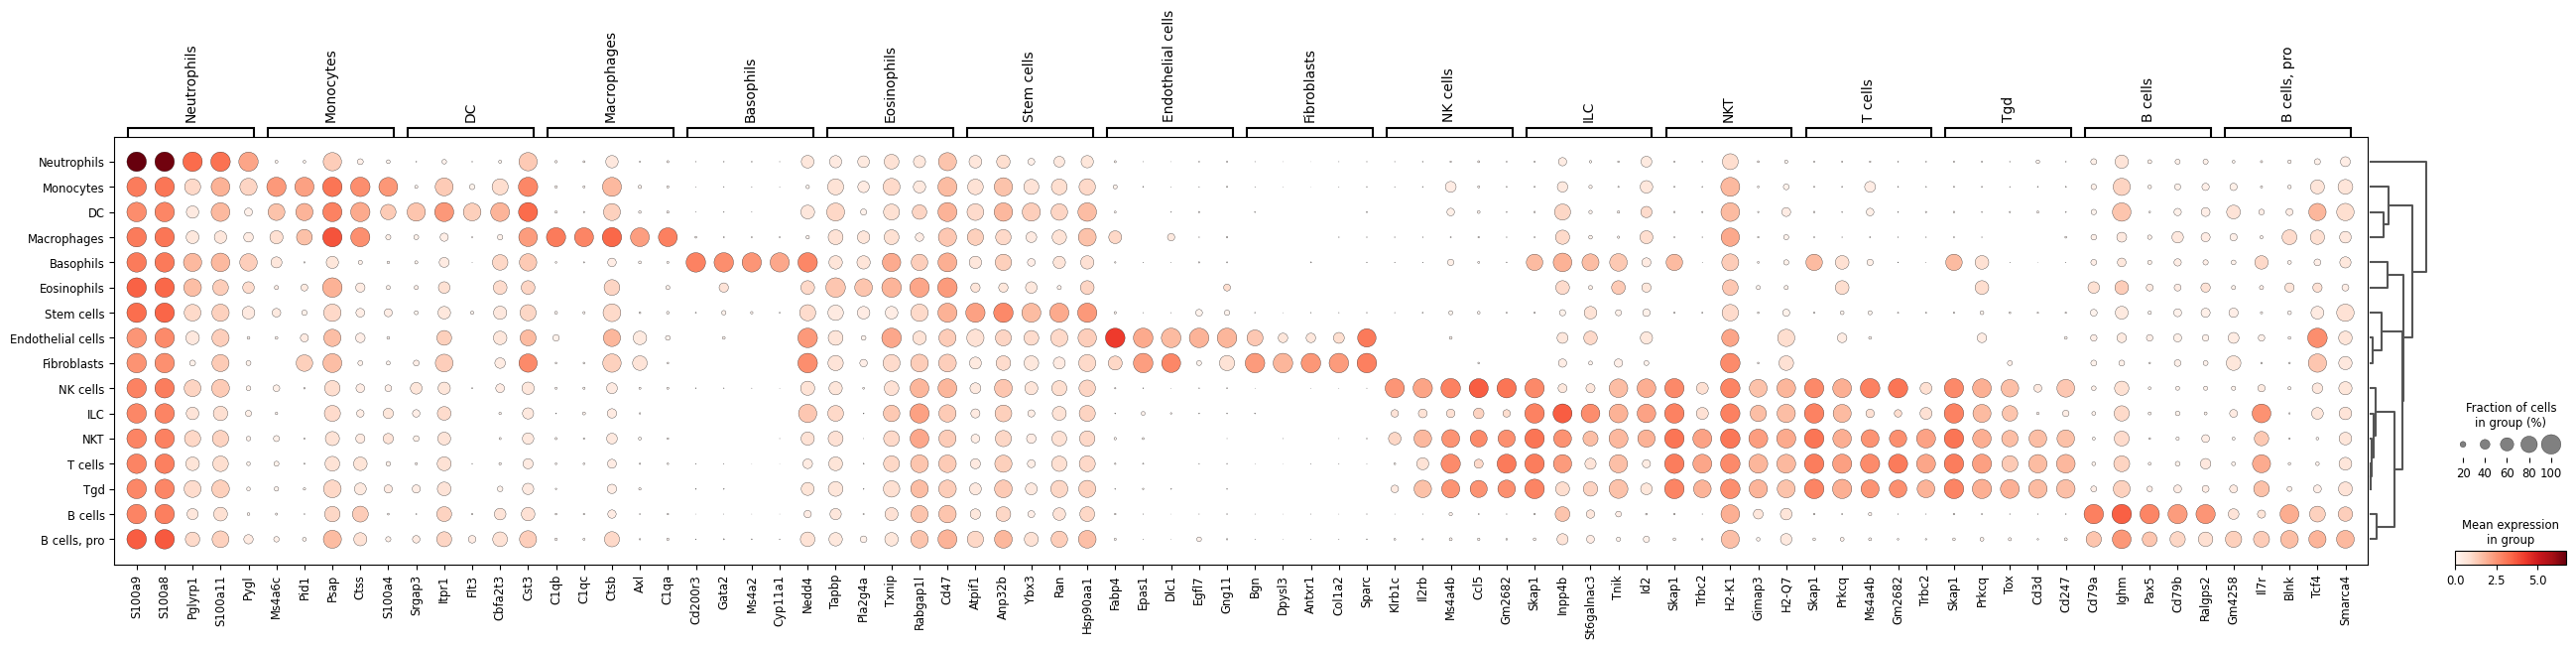

In [24]:
sc.tl.rank_genes_groups(adata_sub_singler, groupby='SingleR_label', method='wilcoxon')
sc.pl.rank_genes_groups_dotplot(adata_sub_singler, n_genes=5, groupby='SingleR_label')